## Importing python libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
holidays_de= holidays.Germany()
import matplotlib.dates as mdates
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)


## Setting color theme

In [6]:
THEME = {
    "actual":   "#1C7ED6",
    "forecast": "#FF922B",
    "renew":    "#2B9348",
    "risk":     "#E03131",
    "text":     "#212529",
    "grid":     "#DEE2E6",
    "muted":    "#868E96",
    "bg":       "#FFFFFF"
}
#ax.tick_params(axis='both', labelsize=14)
def set_style():
    sns.set_theme(style="whitegrid")
    mpl.rcParams.update({
        # Figure
        "figure.facecolor": THEME["bg"],
        "axes.facecolor": THEME["bg"],
        "savefig.facecolor": THEME["bg"],
        "figure.dpi": 120,
        "savefig.dpi": 300,

        # Text
        "text.color": THEME["text"],
        "axes.labelcolor": THEME["text"],
        "xtick.color": THEME["text"],
        "ytick.color": THEME["text"],
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 12,

        # Lines
        "lines.linewidth": 1.5,

        # Grid
        "grid.color": THEME["grid"],
        "grid.linewidth": 1.0,
        "grid.alpha": 1.0,

        # Spines
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": THEME["grid"],

        # Legend
        "legend.frameon": False,
        "legend.fontsize": 11,

        # Default color cycle (order matters)
        "axes.prop_cycle": mpl.cycler(color=[
            THEME["actual"], THEME["forecast"], THEME["renew"],
            THEME["risk"], "#845EF7", "#12B886", "#495057"
        ])
    })

set_style()

## Loading Preprocessed Data

In [7]:
df_all= pd.read_csv('../data/processed/clean_data.csv')
df_all.head()

,date,year,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,10.07,2019-01-01 00:00:00+00:00,2019-01-01 01:00:00+00:00,...,25669.0050,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,2019-01-01 02:00:00+00:00,...,27384.1025,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,-9.91,2019-01-01 02:00:00+00:00,2019-01-01 03:00:00+00:00,...,29010.1275,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,-7.41,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+00:00,...,30359.5675,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,-12.55,2019-01-01 04:00:00+00:00,2019-01-01 05:00:00+00:00,...,31409.2100,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [8]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61367 entries, 0 to 61366
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              61367 non-null  object 
 1   year              61367 non-null  int64  
 2   month             61367 non-null  int64  
 3   day               61367 non-null  int64  
 4   dayofyear         61367 non-null  int64  
 5   hour              61367 non-null  int64  
 6   dayofweek         61367 non-null  int64  
 7   price             61367 non-null  float64
 8   period_start_utc  61367 non-null  object 
 9   period_end_utc    61367 non-null  object 
 10  load_forecast_da  61367 non-null  float64
 11  off_wind_da       61367 non-null  float64
 12  on_wind_da        61367 non-null  float64
 13  solar_da          61367 non-null  float64
 14  gen_forecast_da   61367 non-null  float64
 15  res_sum_da        61367 non-null  float64
 16  dayofyear_sin1    61367 non-null  float6

## converting date columns into datetime format and setting timestamp as index 


In [9]:
df = df_all.copy()
df['period_start_utc'] = pd.to_datetime(df['period_start_utc'],utc=True)
df['period_end_utc'] = pd.to_datetime(df['period_end_utc'],utc=True)
df =df.set_index('period_start_utc')
df = df.sort_index()
df.head()

,date,year,month,day,dayofyear,hour,dayofweek,price,period_end_utc,load_forecast_da,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,2019-01-01,2019,1,1,1,0,1,10.07,2019-01-01 01:00:00+00:00,41692.5650,...,25669.0050,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
2019-01-01 01:00:00+00:00,2019-01-01,2019,1,1,1,1,1,-4.08,2019-01-01 02:00:00+00:00,40587.2325,...,27384.1025,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2019-01-01 02:00:00+00:00,2019-01-01,2019,1,1,1,2,1,-9.91,2019-01-01 03:00:00+00:00,40308.2500,...,29010.1275,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
2019-01-01 03:00:00+00:00,2019-01-01,2019,1,1,1,3,1,-7.41,2019-01-01 04:00:00+00:00,40659.5750,...,30359.5675,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
2019-01-01 04:00:00+00:00,2019-01-01,2019,1,1,1,4,1,-12.55,2019-01-01 05:00:00+00:00,40947.7300,...,31409.2100,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


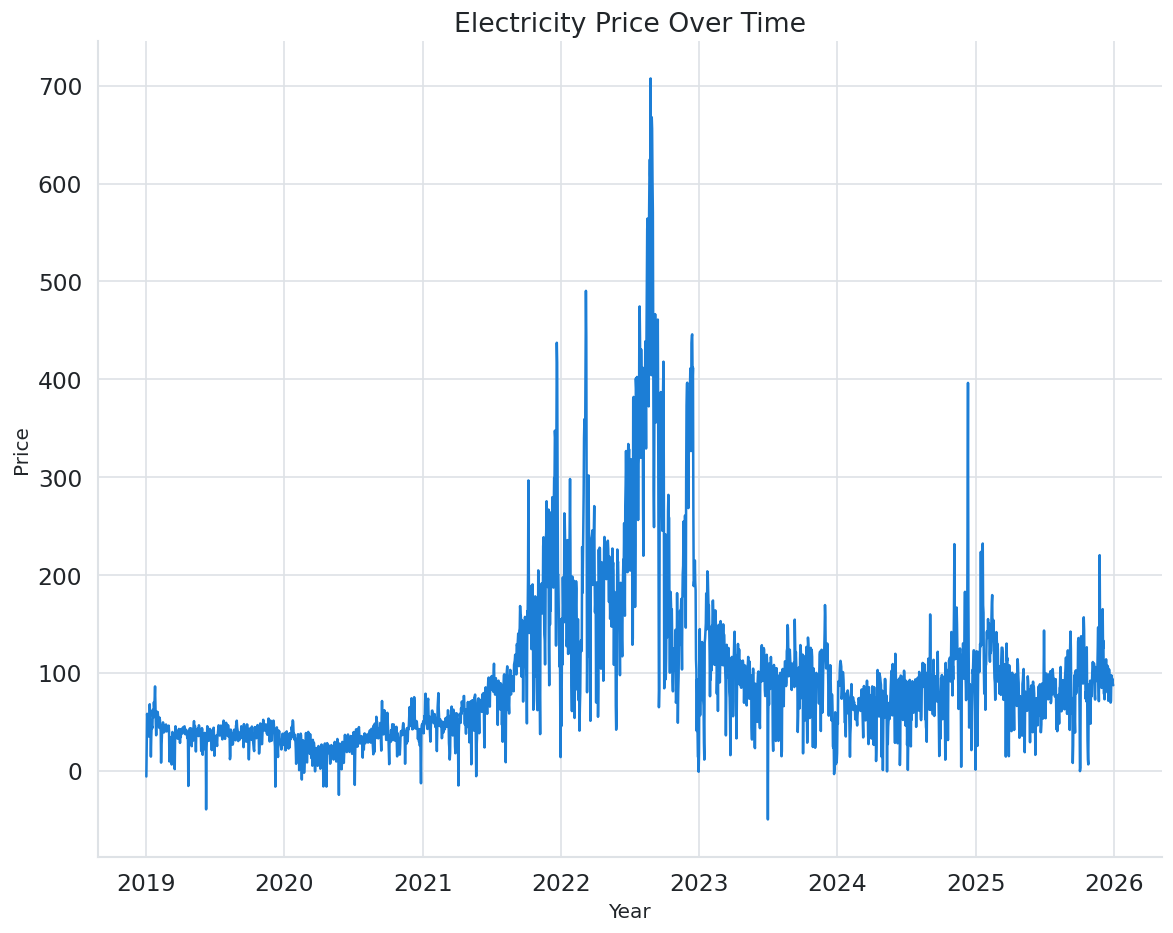

In [10]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df_daily = df.set_index('date')['price'].resample('D').mean().reset_index()
df_daily.head()
fig, ax = plt.subplots(figsize=(10,8))
ax.plot(df_daily['date'], df_daily['price'], color=THEME["actual"])
ax.tick_params(axis='both', labelsize=14)
ax.set_title("Electricity Price Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Price")
plt.tight_layout()

# Plot of Daily Price Fluctuations over each year
This plot explains how prices are varying over the year in each year and an abnormal behavior can be seen for 2022.

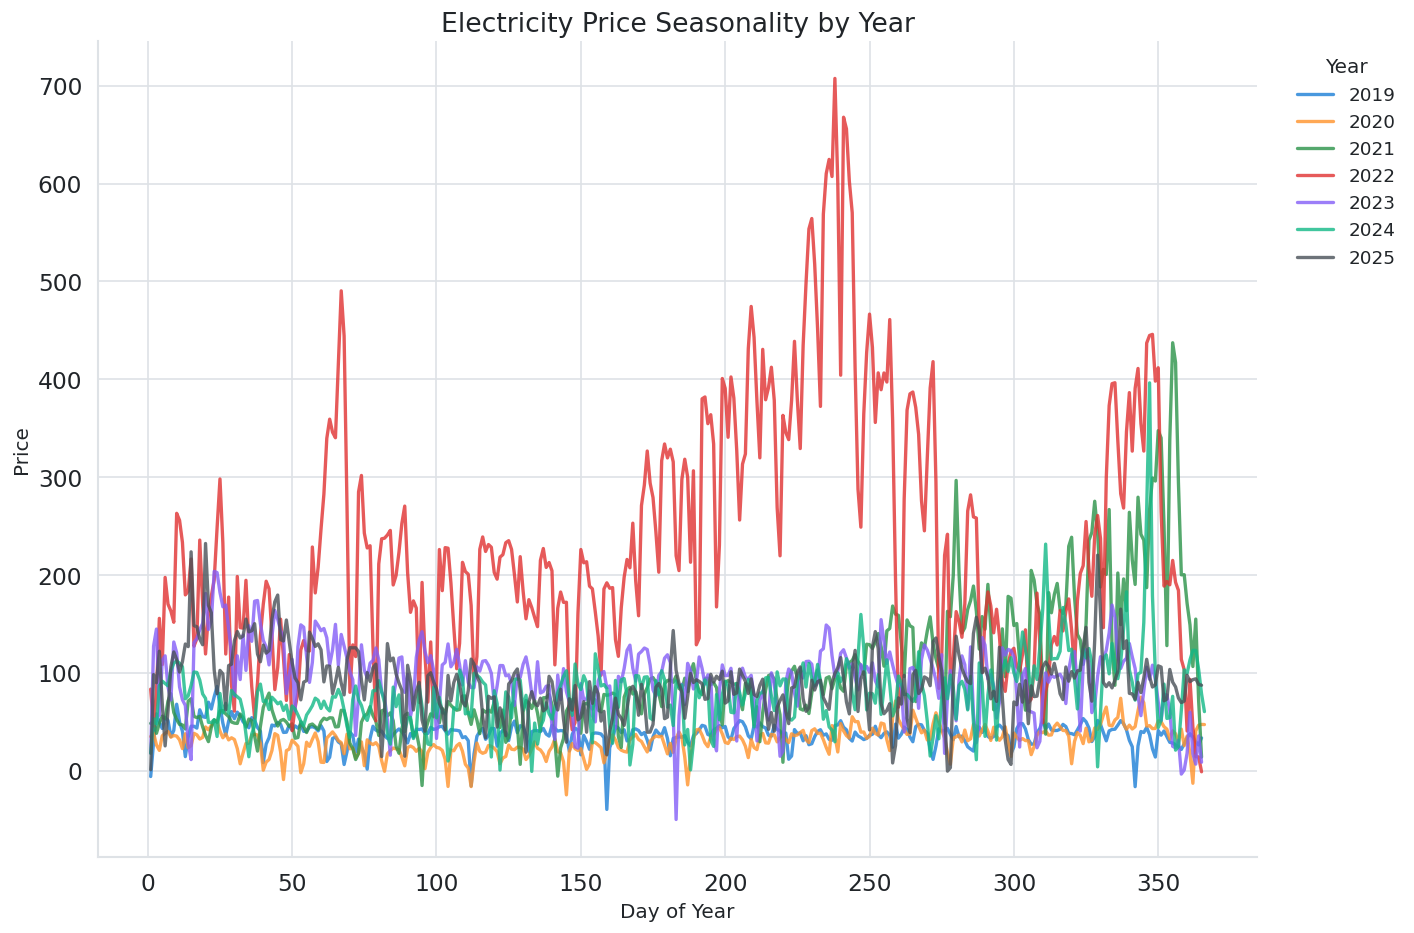

In [11]:
fig, ax = plt.subplots(figsize=(12,8))

pivot = pd.pivot_table(
    data=df[['year','dayofyear','price']],
    index='dayofyear',
    columns='year',
    values='price'
)
pivot_smooth = pivot.rolling(1, center=True).mean()
pivot_smooth.plot(
    ax=ax,
    alpha=0.8,
    linewidth=2
)
ax.set_title("Electricity Price Seasonality by Year", fontsize=16)
ax.set_xlabel("Day of Year")
ax.set_ylabel("Price")
ax.grid(True, color=THEME["grid"], linewidth=1)
ax.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()

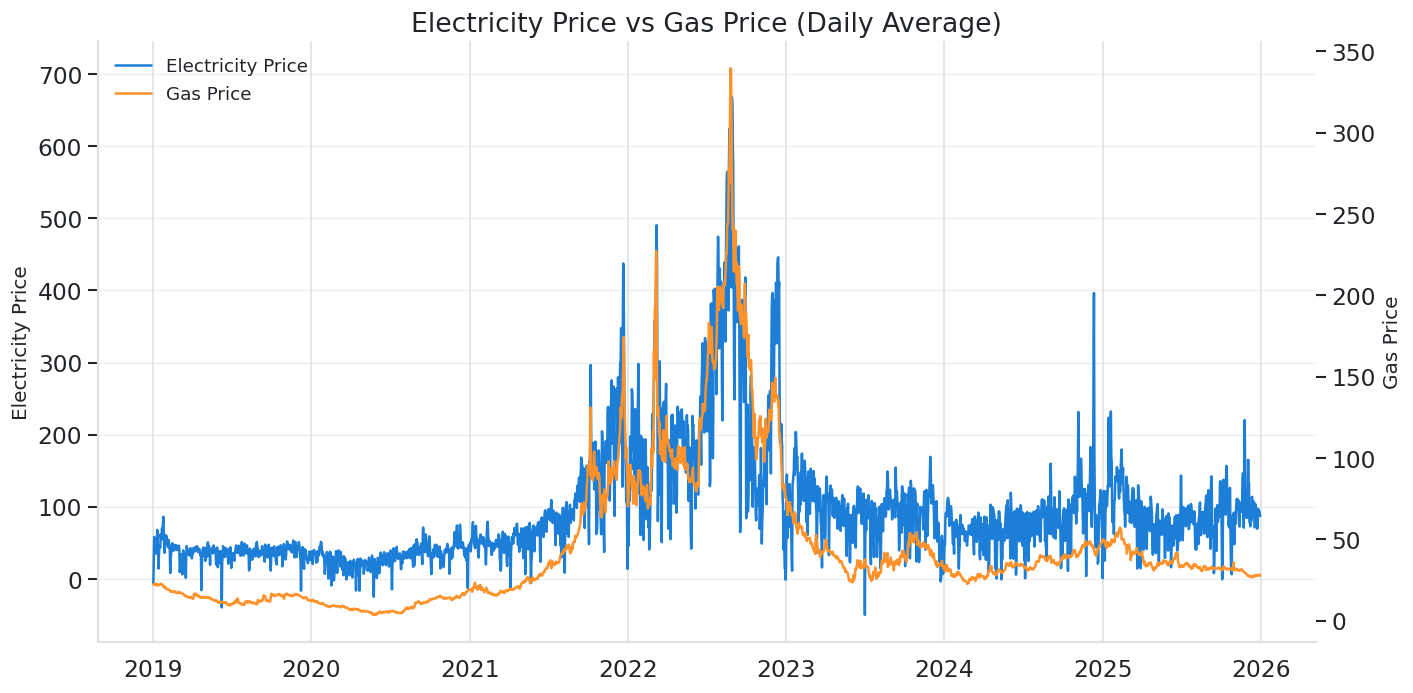

In [12]:
fig, ax1 = plt.subplots(figsize=(12,6))
daily = (
    df.set_index('date')
      .resample('D')
      .agg({
          'price': 'mean',
          'price_gas': 'mean'
      })
      .dropna()
      .reset_index()
)


ax1.plot(daily['date'], daily['price'],
         color=THEME["actual"], label="Electricity Price")

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['price_gas'],
         color=THEME["forecast"], label="Gas Price")

ax1.set_ylabel("Electricity Price")
ax2.set_ylabel("Gas Price")
ax1.set_title("Electricity Price vs Gas Price (Daily Average)")


ax1.grid(axis='y', color=THEME["grid"], linewidth=0.8, alpha=0.6)
ax2.grid(False)


ax1.xaxis.set_major_locator(locator)
ax1.xaxis.set_major_formatter(formatter)

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")
ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
plt.tight_layout()


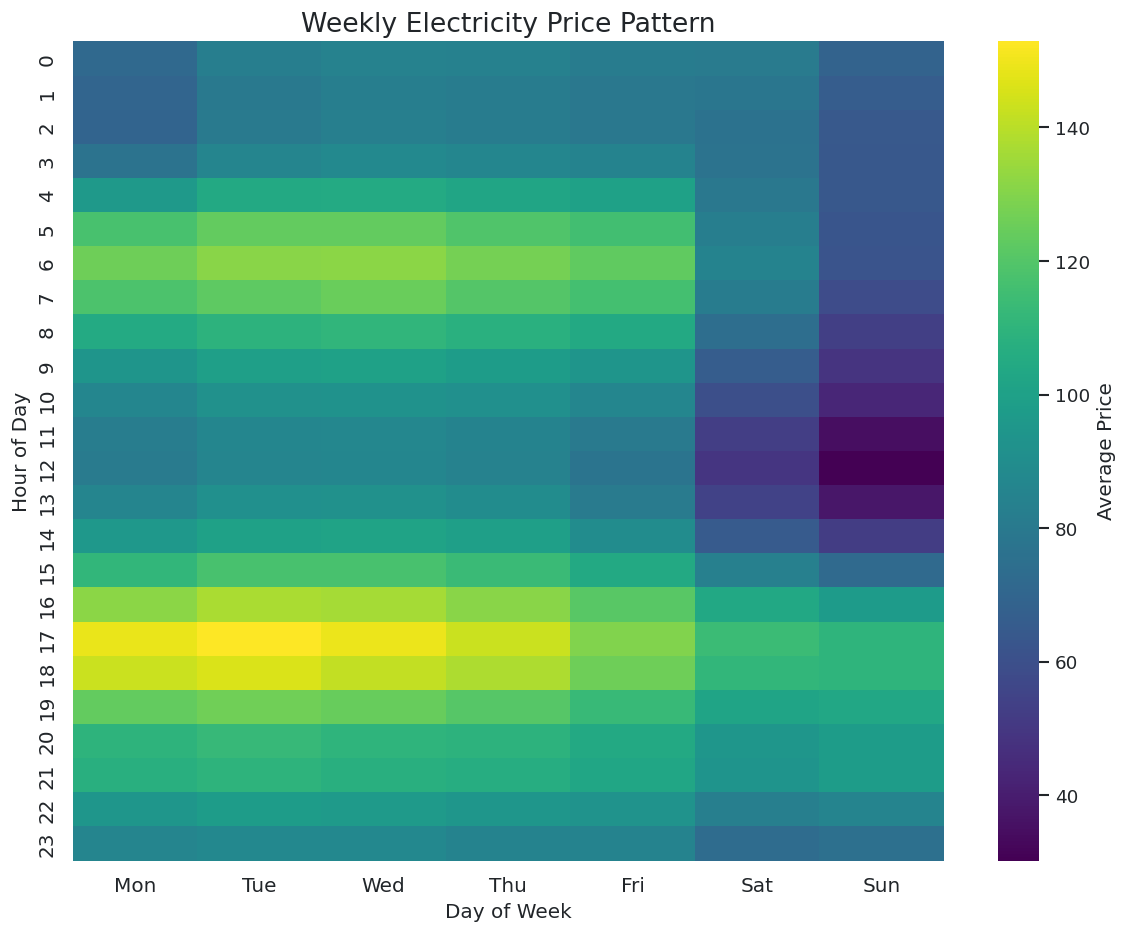

In [13]:
weekly = (
    df.groupby(['dayofweek', 'hour'])['price']
      .mean()
      .reset_index()
)

pivot = weekly.pivot(index='hour', columns='dayofweek', values='price')
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot.columns=weekday_names
fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap='viridis',
    ax=ax,
    cbar_kws={'label': 'Average Price'}
)

ax.set_title("Weekly Electricity Price Pattern")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day")
ax.tick_params(axis='both',labelsize=12)
plt.tight_layout()
plt.show()

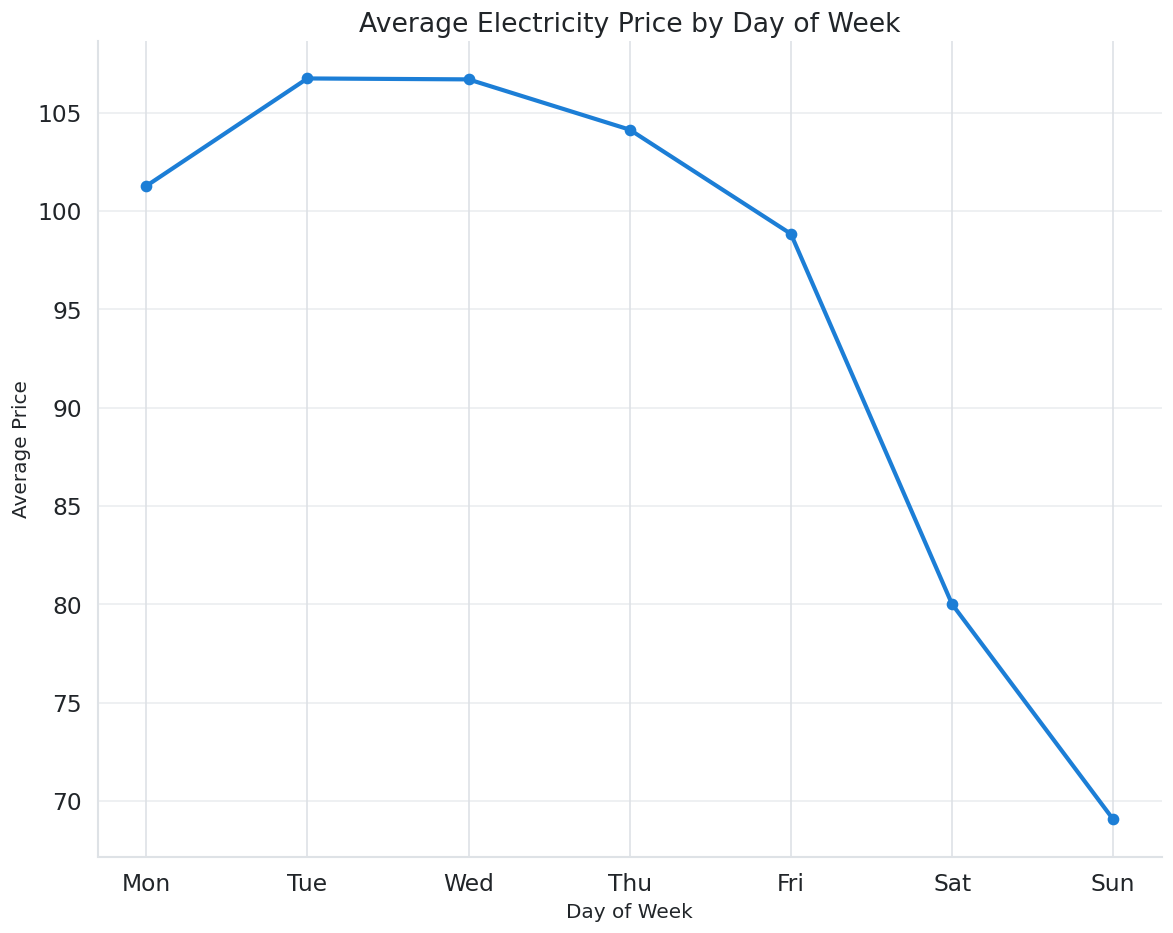

In [14]:
weekly_mean = df.groupby('dayofweek')['price'].mean().reset_index()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fig, ax = plt.subplots(figsize=(10,8))
ax.plot(weekday_names, weekly_mean['price'],
        marker='o', linewidth=2.5, color=THEME["actual"])

ax.set_title("Average Electricity Price by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Price")
ax.grid(axis='y', color=THEME["grid"], alpha=0.6)
ax.tick_params(axis='both',labelsize=14)
plt.tight_layout()

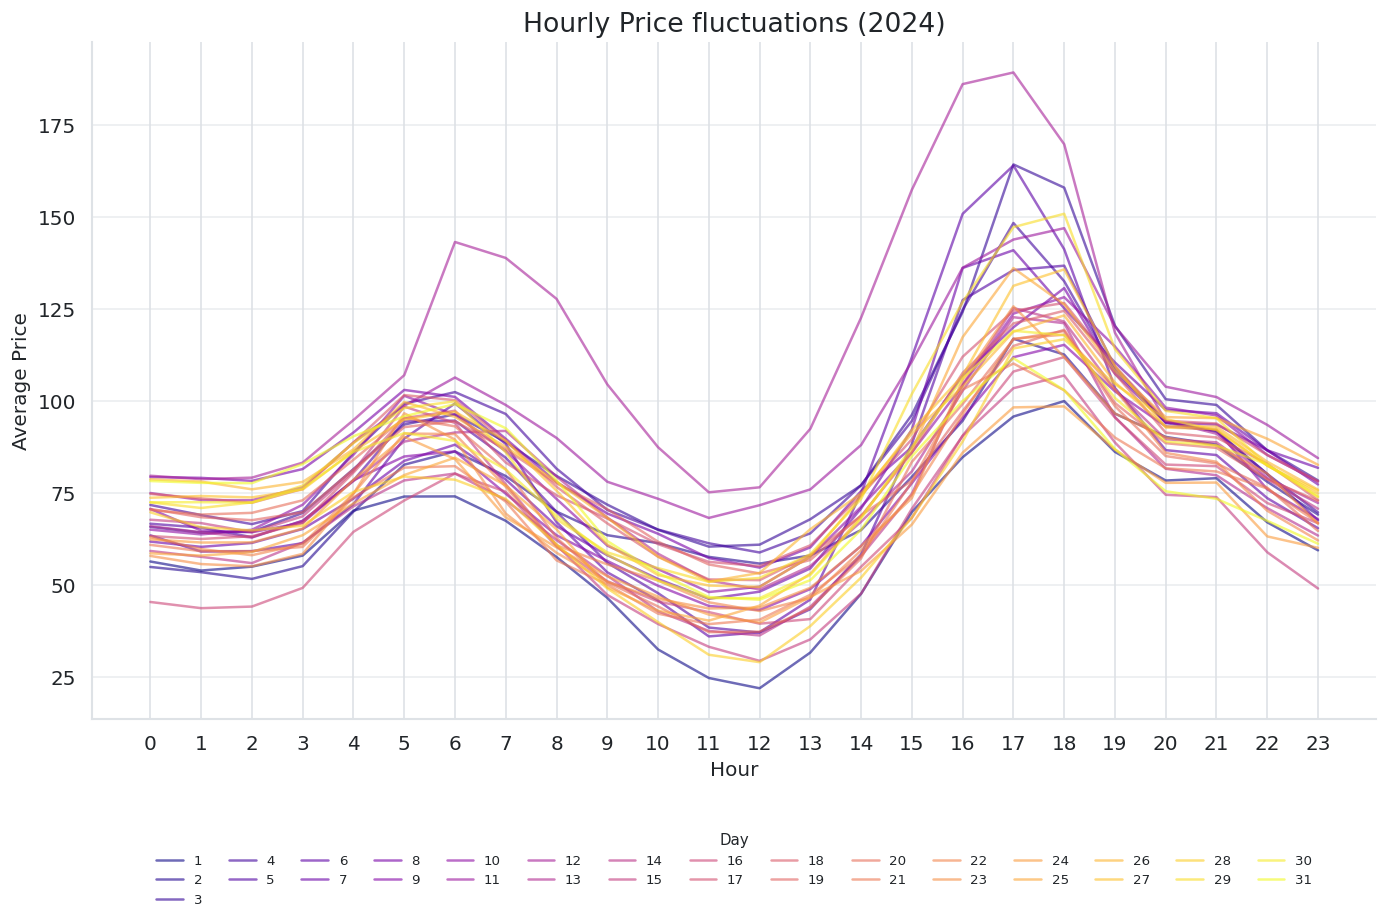

In [15]:
year_to_plot = 2024

df_year = df[df['year'] == year_to_plot].copy()
df_year['day'] = df_year['date'].dt.day

pivot = (
    df_year.groupby(['day','hour'])['price']
           .mean()
           .reset_index()
           .pivot(index='hour', columns='day', values='price')
)

fig, ax = plt.subplots(figsize=(12,8))

pivot.plot(ax=ax, alpha=0.6, linewidth=1.5, cmap='plasma')

ax.set_title(f"Hourly Price fluctuations ({year_to_plot})",fontsize=16)
ax.set_xlabel("Hour")
ax.set_ylabel("Average Price")
ax.set_xticks(range(24))
ax.grid(axis='y', color=THEME["grid"], alpha=0.6)
ax.legend(
    title="Day",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),   # move below plot
    ncol=15,                         # number of columns (adjust)
    fontsize=8,                     # smaller text
    title_fontsize=9,
    frameon=False
)
ax.tick_params(axis='both',labelsize=12)
plt.tight_layout()
plt.show()

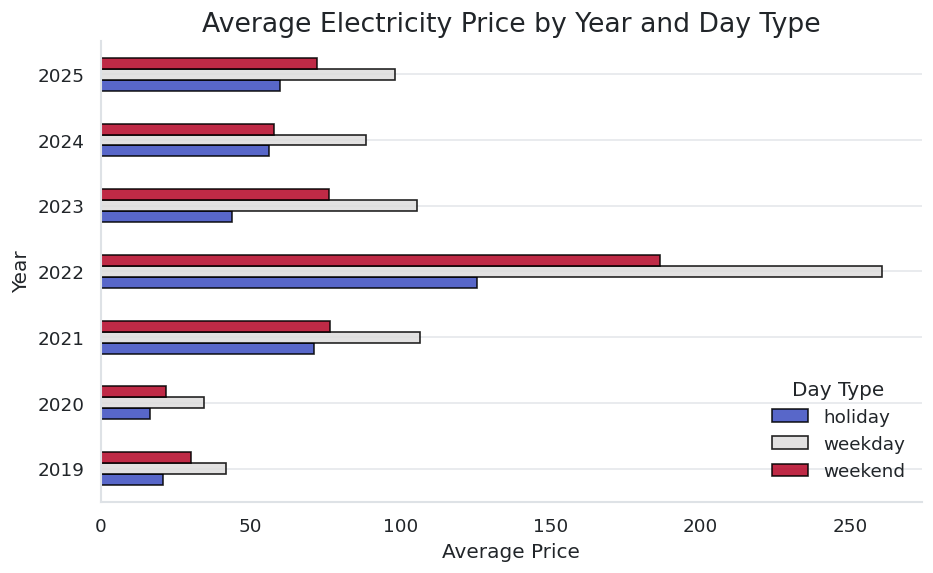

In [16]:
fig, ax = plt.subplots(figsize=(8,5))

# aggregate
df_y = (
    df.groupby(['year','day_type'])['price']
      .mean()
      .reset_index()
)

# pivot
pivot = df_y.pivot(index='year', columns='day_type', values='price').sort_index()



pivot.plot(
    kind='barh',
    cmap='coolwarm',
    alpha=0.85,
    edgecolor='black',
    ax=ax
)

# labels
ax.set_title("Average Electricity Price by Year and Day Type")
ax.set_xlabel("Average Price")
ax.set_ylabel("Year")

# clean grid
ax.grid(axis='y', color=THEME["grid"], alpha=0.8)
ax.grid(axis='x', visible=False)

# clean legend
ax.legend(title="Day Type", bbox_to_anchor=(1.0,0.3), loc='upper right')

plt.tight_layout()
plt.show()

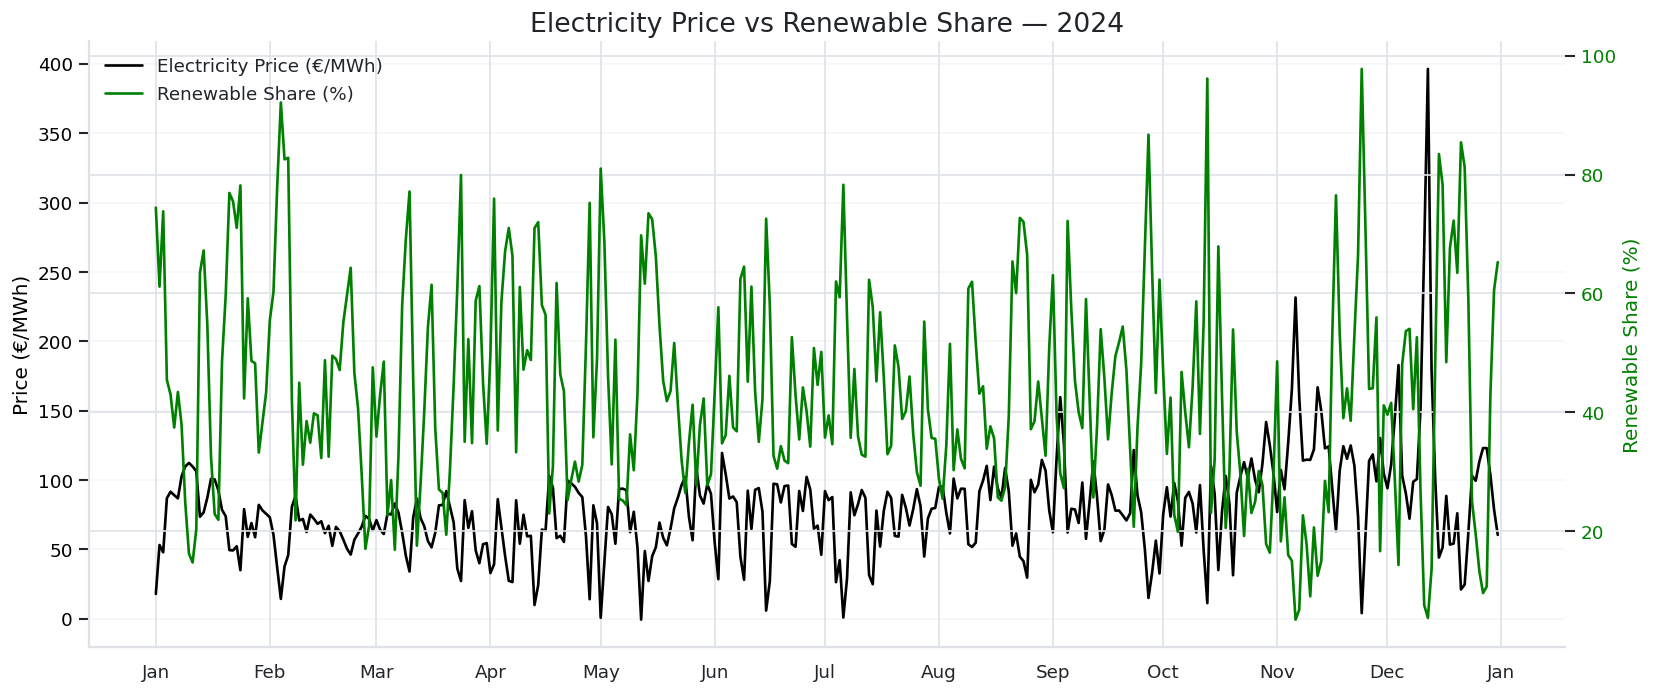

In [17]:

df_plot = df[df["year"] == 2024]


df_daily = df_plot[["price", "res_sum_da", "load_forecast_da"]].resample("D").mean()


df_daily["renewable_share"] = (
    df_daily["res_sum_da"] / df_daily["load_forecast_da"] * 100
)


fig, ax1 = plt.subplots(figsize=(14,6))


color_price = "black"
ax1.plot(df_daily.index, df_daily["price"],
         color=color_price, linewidth=1.6,
         label="Electricity Price (€/MWh)")
ax1.set_ylabel("Price (€/MWh)", color=color_price)
ax1.tick_params(axis="y", labelcolor=color_price)


ax2 = ax1.twinx()
color_res = "green"
ax2.plot(df_daily.index, df_daily["renewable_share"],
         color=color_res, linewidth=1.6,
         label="Renewable Share (%)")
ax2.set_ylabel("Renewable Share (%)", color=color_res)
ax2.tick_params(axis="y", labelcolor=color_res)

ax1.set_title("Electricity Price vs Renewable Share — 2024")

ax1.grid(axis="y", alpha=0.3)
ax2.set_xlabel('month')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))  

plt.setp(ax1.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()